<img src="images/image01.png" alt="Project image" style="display: block; margin: 0 auto;">


# CS618 Project: Data-Efficient Learning from EMG Signals

**Course:** CS618 — Advanced Robotics and Automation  
**Semester:** Second 2025/2026  
**Student:** Mohammed Mizan Alanazi (446540203)  
**Supervisor:** Prof. Yassine Saleh Bouteraa  
**Institution:** Prince Sattam bin Abdulaziz University

---


<img src="images/logo.svg" alt="University logo" style="width: 400px; display: block; margin: 0 auto;">


## Table of Contents

1. [Project Overview](#1-project-overview)
2. [Problem Statement](#2-problem-statement)
3. [Dataset Description](#3-dataset-description)
4. [Gesture Selection](#4-gesture-selection)
5. [System Architecture](#5-system-architecture)
6. [Data Pipeline & Preprocessing](#6-data-pipeline--preprocessing)
7. [Model Architecture](#7-model-architecture)
8. [Training](#8-training)
9. [Training Curves](#9-training-curves)
10. [Evaluation Metrics](#10-evaluation-metrics)
11. [Test Evaluation](#11-test-evaluation)
12. [Majority Voting Evaluation](#12-majority-voting-evaluation)
13. [Results Summary](#13-results-summary)
14. [Data Leakage Prevention Checklist](#14-data-leakage-prevention-checklist)
15. [References](#15-references)

---


## Import Libraries 📚

In [ ]:
import os
import sys
import random
import json
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.manifold import TSNE
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch

_cwd = os.path.abspath("")
BASE_DIR = _cwd if os.path.exists(os.path.join(_cwd, "config.yaml")) else os.path.dirname(_cwd)
sys.path.insert(0, BASE_DIR)
from src.utils import get_device, set_seed
from src.train import bandpass_filter, notch_filter, add_gaussian_noise, mixup_data, mixup_criterion

print("Libraries imported successfully! ✅")


Libraries imported successfully! ✅


## Configuration Setup ⚙️

Load experiment configuration from `config.yaml`.

In [ ]:
config_path = os.path.join(BASE_DIR, "config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

WINDOW_SIZE = config["window_size"]
WINDOW_STEP = config["window_step"]
SEED = config["seed"]
N_CLASSES = config["n_classes"]
N_CHANNELS = config["n_channels"]
FS = config["fs"]
GESTURE_NAMES = config["gesture_names"]
GESTURE_MAP = config["gesture_map"]
CHANNELS = config["channels"]
KERNEL_SIZES = config["kernel_sizes"]

set_seed(SEED)
device = get_device()

print(f"Config loaded from {config_path} ✅")
print(f"Device: {device}")
print(f"Window size: {WINDOW_SIZE}, Step: {WINDOW_STEP}, Seed: {SEED}")


Config loaded from /Users/maohammed/Documents/Applied/CS618_final_april copy 2/config.yaml ✅
Device: mps
Window size: 200, Step: 50, Seed: 123


## 1. Project Overview 🔍

This notebook implements a **1D-CNN ResCNN architecture** for cross-subject EMG gesture classification.
Five gestures are selected from the NinaPro DB2 dataset, and sliding windows (200 samples, 75% overlap) are classified and aggregated via **majority voting** to produce robust per-gesture predictions.

---

## 2. Problem Statement 🎯

### Cross-Subject EMG Variability
The same gesture produces different signal patterns across individuals due to muscle anatomy, electrode placement, and fatigue. This makes cross-subject generalization challenging.

### Why a Simple Architecture Was Chosen
Complex models are prone to overfitting on small EMG datasets. A compact **ResCNN with 3 residual blocks** (~647K parameters) provides sufficient capacity while regularizing via BatchNorm, GELU, Dropout (0.5), adaptive mixup, and Gaussian noise augmentation.

### Data Scarcity and Generalization Challenge
With only 40 subjects and 5 gesture classes, the model must learn discriminative features that transfer to unseen subjects without subject-specific fine-tuning.

---


## 3. Dataset Description 📊

### NinaPro DB2 Overview

| Property | Value |
|---|---|
| Subjects | 40 healthy individuals |
| Channels | 12 sEMG electrodes (Delsys Trigno) |
| Sampling rate | 2000 Hz |
| Selected gestures | 5 (Rest, Fist, LargeGrasp, WristPron, Tripod) |
| Repetitions per gesture | 6 |

The filtered subset is located in `data/subset/` as `.npy` files (one per subject).

---


## 4. Gesture Selection 🖐️

Five gestures were selected to cover essential robotic arm control commands:

| Label ID | Gesture Name | Robotic Function | Mapped Class | Image |
|---|---|---|---|---|
| 0 | Rest | Idle / Stop | 0 | <img src="images/Rest.png" width="150"> |
| 6 | Fingers flexed in fist | Close gripper | 1 | <img src="images/Fingers-flexed-together-in-fist.png" width="150"> |
| 17 | Large diameter grasp | Open gripper wide | 2 | <img src="images/Large-diameter-grasp.png" width="150"> |
| 25 | Wrist pronation | Rotate wrist CW | 3 | <img src="images/Wrist-pronation.png" width="150"> |
| 38 | Tripod grasp | Precision grasp | 4 | <img src="images/Tripod-grasp.png" width="150"> |

---


## 5. System Architecture 🏗️

```
Raw EMG (12 channels, 2000Hz)
    ↓
Bandpass Filter (20-450Hz) + Notch (50Hz)
    ↓
Z-score Normalization (per-subject)
    ↓
Sliding Windows (200pt, step=50)
    ↓
ResCNN (3 ResBlocks: 64→128→256)
    ↓
Softmax
    ↓
Majority Voting (Hard + Soft)
    ↓
Final Gesture Prediction
```

### Model Architecture Summary
- **Stem**: Conv1d(12→64, k=15) → BN → GELU → MaxPool1d(2)
- **ResBlock 1**: Conv1d(64→64, k=15) → BN → GELU → Conv1d(64→64, k=15) → BN → GELU → shortcut → MaxPool1d(2)
- **ResBlock 2**: Conv1d(64→128, k=7) → BN → GELU → Conv1d(128→128, k=7) → BN → GELU → shortcut → MaxPool1d(2)
- **ResBlock 3**: Conv1d(128→256, k=3) → BN → GELU → Conv1d(256→256, k=3) → BN → GELU → shortcut → MaxPool1d(2)
- **Head**: AdaptiveAvgPool1d(1) → Dropout(0.5) → Linear(256→5)

---


## 6. Data Pipeline & Preprocessing ⚙️

In [ ]:
all_subjects = np.arange(1, 41)
train_val, test = train_test_split(all_subjects, test_size=10, random_state=SEED)
train_ids, val_ids = train_test_split(train_val, test_size=6, random_state=SEED)
train_ids = sorted(train_ids.tolist())
val_ids = sorted(val_ids.tolist())
test_ids = sorted(test.tolist())

print(f"Train subjects ({len(train_ids)}): {train_ids}")
print(f"Val subjects   ({len(val_ids)}): {val_ids}")
print(f"Test subjects  ({len(test_ids)}): {test_ids}")

def count_windows(subject_ids):
    counts = np.zeros(N_CLASSES, dtype=int)
    for sid in subject_ids:
        lbls = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_labels.npy"))
        for i in range(0, len(lbls) - WINDOW_SIZE, WINDOW_STEP):
            c = i + WINDOW_SIZE // 2
            l = lbls[c]
            if l in GESTURE_MAP:
                counts[GESTURE_MAP[l]] += 1
    return counts

train_counts = count_windows(train_ids)
val_counts = count_windows(val_ids)
test_counts = count_windows(test_ids)

print("\nClass distribution (window counts):")
for i, name in enumerate(GESTURE_NAMES):
    print(f"  {name:12s}  train={train_counts[i]:>10,}  val={val_counts[i]:>10,}  test={test_counts[i]:>10,}")
print(f"Train/val split computed! ✅")


Train subjects (24): [1, 4, 5, 8, 9, 10, 15, 16, 17, 19, 20, 23, 25, 26, 27, 28, 29, 30, 31, 33, 34, 36, 37, 38]
Val subjects   (6): [3, 18, 22, 32, 35, 40]
Test subjects  (10): [2, 6, 7, 11, 12, 13, 14, 21, 24, 39]

Class distribution (window counts):
  Rest          train=    38,696  val=     9,609  test=    15,391
  Fist          train=    20,936  val=     5,315  test=    11,690
  LargeGrasp    train=    20,310  val=     4,776  test=     9,114
  WristPron     train=    28,979  val=     8,085  test=    12,756
  Tripod        train=    32,622  val=     8,162  test=    13,136
Train/val split computed! ✅


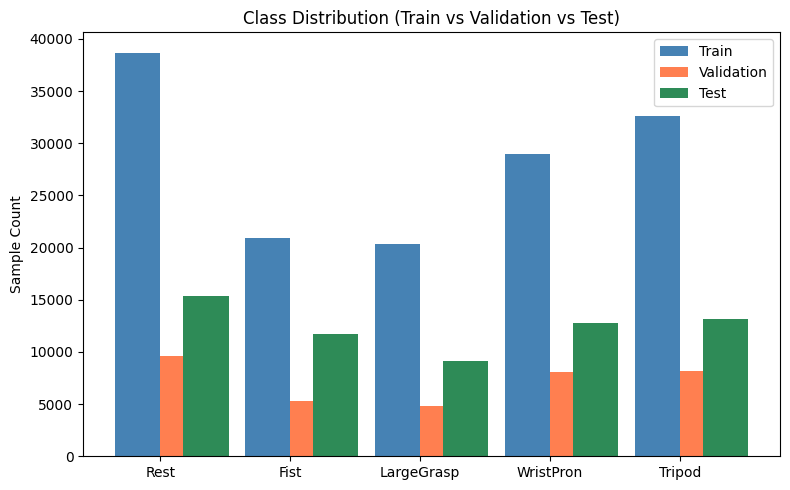

Saved to /Users/maohammed/Documents/Applied/CS618_final_april copy 2/results/class_distribution.png ✅


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(N_CLASSES)
width = 0.35
bars1 = ax.bar(x - width/2, train_counts, width, label="Train", color="steelblue")
bars2 = ax.bar(x + width/2, val_counts, width, label="Validation", color="coral")
bars3 = ax.bar(x + width, test_counts, width, label="Test", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(GESTURE_NAMES)
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution (Train vs Validation vs Test)")
ax.legend()
plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "class_distribution.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved to {out_path} ✅")


### Preprocessing Pipeline

Applied **per-subject** to prevent data leakage:

1. **Bandpass filter:** 20–450 Hz (4th-order Butterworth, zero-phase `sosfiltfilt`)
2. **Notch filter:** 50 Hz (powerline interference removal via `iirnotch`)
3. **Z-score normalization:** Per-channel using each subject's own mean and standard deviation

$$x_{\text{norm}} = \frac{x - \mu_{\text{subject}}}{\sigma_{\text{subject}} + \epsilon}$$

---


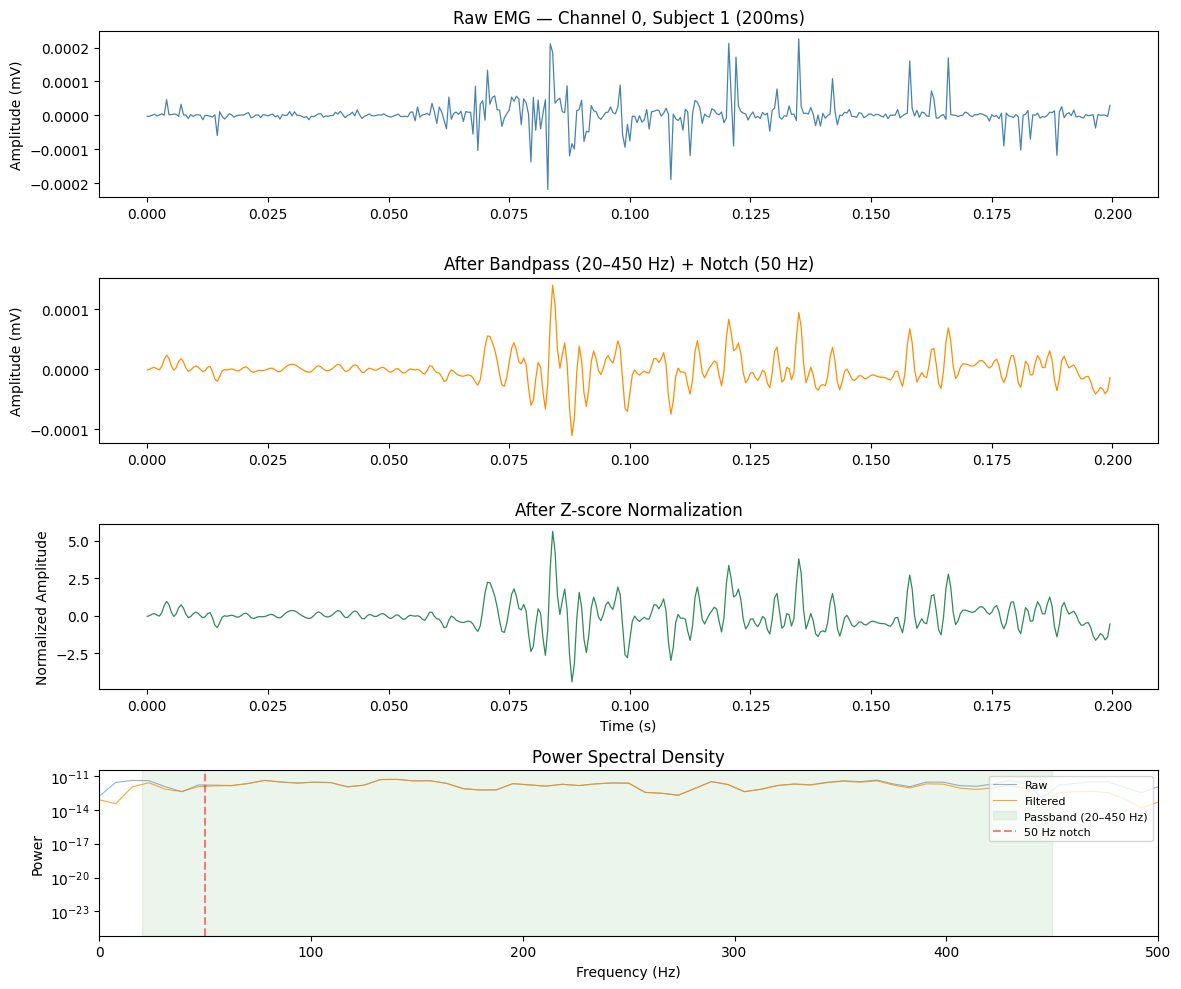

Preprocessing comparison plot saved to /Users/maohammed/Documents/Applied/CS618_final_april copy 2/results/preprocessing_comparison.png ✓


In [ ]:
def bandpass_filter(emg, lowcut=20, highcut=450, fs=FS, order=4):
    if emg.ndim == 1:
        emg = emg[np.newaxis, :]
    nyq = 0.5 * fs
    sos = butter(order, [lowcut / nyq, highcut / nyq], btype="band", output="sos")
    filt = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filt[ch] = sosfiltfilt(sos, emg[ch])
    return filt

def notch_filter(emg, freq=50, fs=FS, quality=30):
    if emg.ndim == 1:
        emg = emg[np.newaxis, :]
    w0 = freq / (0.5 * fs)
    b, a = iirnotch(w0, quality)
    filt = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filt[ch] = filtfilt(b, a, emg[ch])
    return filt

sid = 1
emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
raw = emg[:400, 0]  # 200ms, channel 0

bp = bandpass_filter(raw.reshape(1, -1))[0]
bn = notch_filter(bp.reshape(1, -1))[0]
norm = (bn - bn.mean()) / (bn.std() + 1e-8)


fig, axes = plt.subplots(4, 1, figsize=(12, 10))
t = np.arange(len(raw)) / FS

axes[0].plot(t, raw, color="steelblue", linewidth=0.9)
axes[0].set_title("Raw EMG — Channel 0, Subject 1 (200ms)")
axes[0].set_ylabel("Amplitude (mV)")

axes[1].plot(t, bn, color="darkorange", linewidth=0.9)
axes[1].set_title("After Bandpass (20–450 Hz) + Notch (50 Hz)")
axes[1].set_ylabel("Amplitude (mV)")

axes[2].plot(t, norm, color="seagreen", linewidth=0.9)
axes[2].set_title("After Z-score Normalization")
axes[2].set_ylabel("Normalized Amplitude")
axes[2].set_xlabel("Time (s)")

f_raw, p_raw = welch(raw, fs=FS, nperseg=256)
f_filt, p_filt = welch(bn, fs=FS, nperseg=256)
axes[3].semilogy(f_raw, p_raw, alpha=0.6, linewidth=0.8, label="Raw", color="steelblue")
axes[3].semilogy(f_filt, p_filt, alpha=0.8, linewidth=0.8, label="Filtered", color="darkorange")
axes[3].axvspan(20, 450, alpha=0.08, color="green", label="Passband (20–450 Hz)")
axes[3].axvline(50, color="red", linestyle="--", alpha=0.5, label="50 Hz notch")
axes[3].set_xlim(0, 500)
axes[3].set_title("Power Spectral Density")
axes[3].set_xlabel("Frequency (Hz)")
axes[3].set_ylabel("Power")
axes[3].legend(loc="upper right", fontsize=8)

plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "preprocessing_comparison.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Preprocessing comparison plot saved to {out_path} ✓")


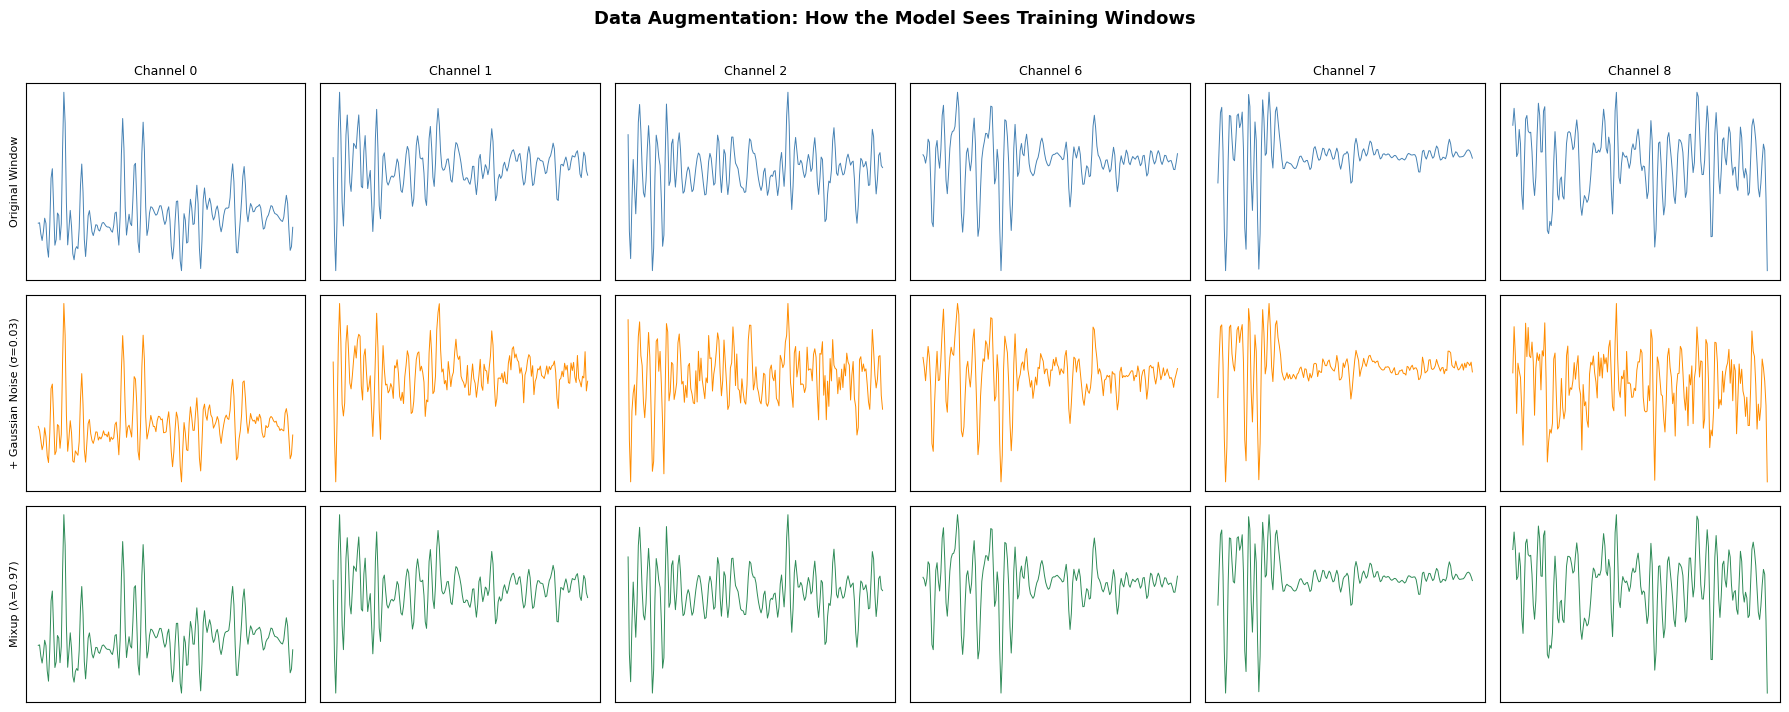

Augmentation visualization saved to /Users/maohammed/Documents/Applied/CS618_final_april copy 2/results/augmentation_visualization.png ✓


In [ ]:
# Build a few windows from Subject 1 for demonstration (no model needed)
sid = 1
emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
emg_t = bandpass_filter(emg.T)
emg_t = notch_filter(emg_t)
emg_filt = emg_t.T.astype(np.float32)
ch_mean = emg_filt.mean(axis=0, keepdims=True)
ch_std = emg_filt.std(axis=0, keepdims=True) + 1e-8
emg_filt = (emg_filt - ch_mean) / ch_std

demo_windows = []
for i in range(0, len(emg_filt) - WINDOW_SIZE, WINDOW_STEP):
    c = i + WINDOW_SIZE // 2
    if emg_filt[i:i + WINDOW_SIZE].shape[0] == WINDOW_SIZE:
        demo_windows.append(emg_filt[i:i + WINDOW_SIZE])
    if len(demo_windows) >= 50:
        break

sample = demo_windows[5]   # (200, 12) — HWC
another = demo_windows[15]

sample_t = torch.from_numpy(sample.copy()).unsqueeze(0).permute(0, 2, 1).to(device)  # (1, 12, 200)
another_t = torch.from_numpy(another.copy()).unsqueeze(0).permute(0, 2, 1).to(device)

aug_noise = sample_t + torch.randn_like(sample_t) * config['gaussian_noise_std']
lam_val = np.random.beta(config['mixup_alpha_early'], config['mixup_alpha_early'])
aug_mixup = lam_val * sample_t + (1 - lam_val) * another_t

channels_to_show = [0, 1, 2, 6, 7, 8]
fig, axes = plt.subplots(3, len(channels_to_show), figsize=(18, 7))
plot_data = [
    ("Original Window", sample_t[0].cpu().numpy(), "steelblue"),
    (f"+ Gaussian Noise (σ={config['gaussian_noise_std']})", aug_noise[0].cpu().numpy(), "darkorange"),
    (f"Mixup (λ={lam_val:.2f})", aug_mixup[0].cpu().numpy(), "seagreen"),
]

for row, (title, data, color) in enumerate(plot_data):
    for col, ch in enumerate(channels_to_show):
        ax = axes[row, col]
        ax.plot(data[ch], color=color, linewidth=0.7)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"Channel {ch}", fontsize=9)
        if col == 0:
            ax.set_ylabel(title, fontsize=8)

fig.suptitle("Data Augmentation: How the Model Sees Training Windows", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "augmentation_visualization.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Augmentation visualization saved to {out_path} ✓")


## 7. Model Architecture 🧠

---


In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.pool = nn.MaxPool1d(2)

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.gelu(self.bn1(self.conv1(x)))
        out = F.gelu(self.bn2(self.conv2(out)))
        return self.pool(out + residual)

class ResCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(N_CHANNELS, CHANNELS[0], kernel_size=15, padding=7),
            nn.BatchNorm1d(CHANNELS[0]),
            nn.GELU(),
            nn.MaxPool1d(2),
        )
        self.block1 = ResBlock(CHANNELS[0], CHANNELS[0], KERNEL_SIZES[0])
        self.block2 = ResBlock(CHANNELS[0], CHANNELS[1], KERNEL_SIZES[1])
        self.block3 = ResBlock(CHANNELS[1], CHANNELS[2], KERNEL_SIZES[2])
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(config["dropout"])
        self.fc = nn.Linear(CHANNELS[2], N_CLASSES)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(self.dropout(x))

model = ResCNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,} trainable")
print("\nModel architecture:")
print(model)
print(f"\nModel defined successfully! ✅")


Model parameters: 646,853 trainable

Model architecture:
ResCNN(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Identity()
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, 

## 8. Training 🚀

The training loop is implemented as a standalone script (`src/train.py`) to keep the notebook clean and to allow training on GPU without Jupyter overhead.

### Hyperparameters

| Parameter | Value |
|---|---|
| Architecture | ResCNN (3 blocks, [64,128,256]) |
| Parameters | ~647K |
| Window size | 200 (100ms) |
| Window step | 50 (75% overlap) |
| Optimizer | AdamW (lr=2e-3, wd=3e-3) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=10) |
| Label smoothing | 0.1 |
| Dropout | 0.5 |
| Mixup | Adaptive (0.25→0.05→off) |
| Max epochs | 100, patience=30 |

---


In [24]:
os.chdir(BASE_DIR)
!python3 src/train.py --data_dir {config['data_dir']} --output_dir {config['output_dir']} --seed {config['seed']}


Device: mps
Data:   data/subset
Output: results/best_model
Seed:   123

Train (24): [1, 4, 5, 8, 9, 10, 15, 16, 17, 19, 20, 23, 25, 26, 27, 28, 29, 30, 31, 33, 34, 36, 37, 38]
Val   (6): [3, 18, 22, 32, 35, 40]
Test  (10): [2, 6, 7, 11, 12, 13, 14, 21, 24, 39]

Train windows: 141543
Val windows:   35947
  Rest         train= 38696  val=  9609
  Fist         train= 20936  val=  5315
  LargeGrasp   train= 20310  val=  4776
  WristPron    train= 28979  val=  8085
  Tripod       train= 32622  val=  8162

Class weights (for sampling): [2.58424643e-05 4.77646160e-05 4.92368291e-05 3.45077470e-05
 3.06541598e-05]

Model: 646,853 trainable parameters
ResCNN(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): ResBlock(
    (conv1): Con

## 9. Training Curves 📈

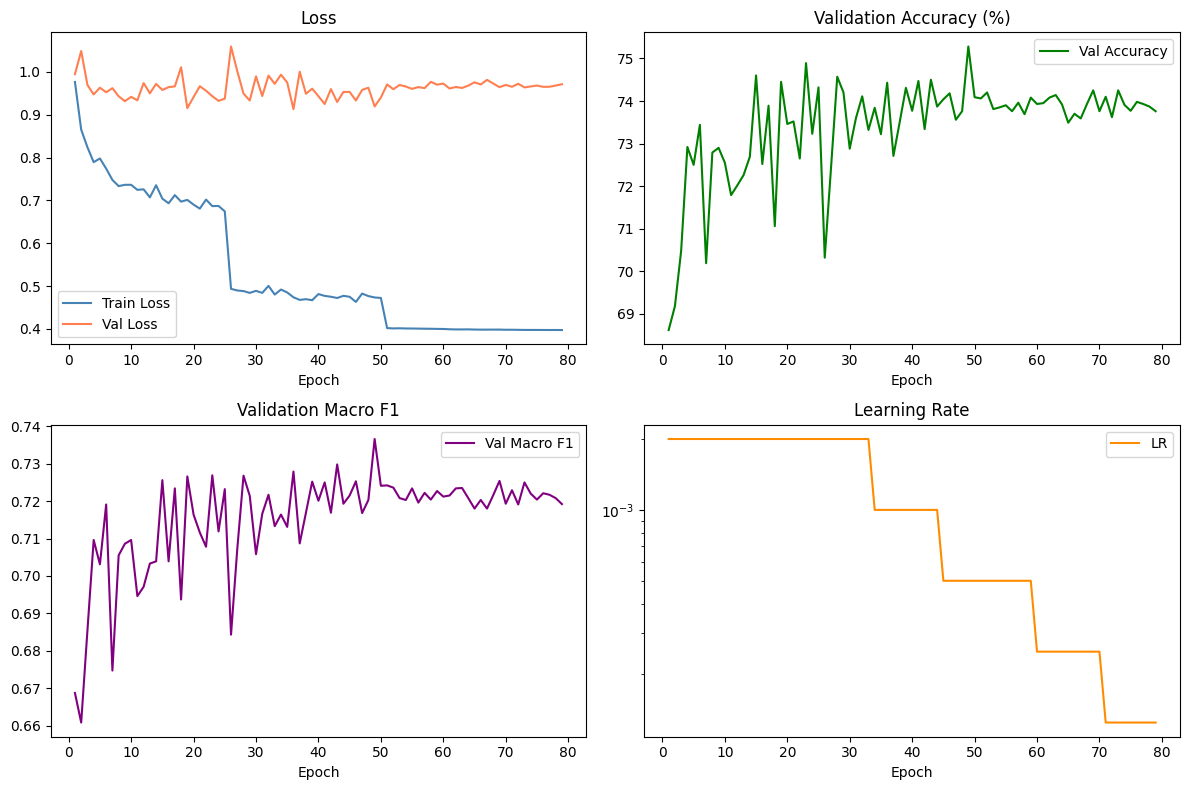

Best val accuracy: 75.28% at epoch 49
Training curves saved! ✅


In [ ]:
hist_path = os.path.join(BASE_DIR, config["output_dir"], "training_history.json")
with open(hist_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0, 0].plot(epochs, history["val_loss"], label="Val Loss", color="coral")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(epochs, history["val_acc"], label="Val Accuracy", color="green")
axes[0, 1].set_title("Validation Accuracy (%)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

axes[1, 0].plot(epochs, history["val_f1"], label="Val Macro F1", color="purple")
axes[1, 0].set_title("Validation Macro F1")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()

axes[1, 1].plot(epochs, history["lr"], label="LR", color="darkorange")
axes[1, 1].set_title("Learning Rate")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_yscale("log")
axes[1, 1].legend()

plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "training_curves.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Best val accuracy: {history['best_val_acc']:.2f}% at epoch {history['best_epoch']}")
print(f"Training curves saved! ✅")


## 10. Evaluation Metrics 📐

### Window-Level Metrics (per 100ms window)

$$Precision_c = \frac{TP_c}{TP_c + FP_c}$$

$$Recall_c = \frac{TP_c}{TP_c + FN_c}$$

$$F1_c = 2 \cdot \frac{Precision_c \cdot Recall_c}{Precision_c + Recall_c}$$

$$Macro\ F1 = \frac{1}{5}\sum_{c=0}^{4} F1_c$$

$$Accuracy = \frac{\sum_{c} TP_c}{Total\ Samples}$$

### Segment-Level (Majority Voting)

$$Hard\ Vote: \hat{y}_{gesture} = \underset{c \in \{0,1,2,3,4\}}{\arg\max} \sum_{i=1}^{N} \mathbb{1}[y_i = c]$$

$$Soft\ Vote: \hat{y}_{gesture} = \underset{c \in \{0,1,2,3,4\}}{\arg\max} \sum_{i=1}^{N} P(y_i = c)$$

where $N$ = number of windows in that continuous gesture segment.

---


## 11. Test Evaluation 🧪

Best checkpoint loaded successfully! ✅

Window-Level Results:
  Accuracy:  69.87%
  Macro F1:  0.6805

              precision    recall  f1-score   support

        Rest       0.99      1.00      1.00     15391
        Fist       0.72      0.51      0.60     11690
  LargeGrasp       0.66      0.72      0.69      9114
   WristPron       0.58      0.44      0.50     12756
      Tripod       0.53      0.75      0.62     13136

    accuracy                           0.70     62087
   macro avg       0.70      0.68      0.68     62087
weighted avg       0.71      0.70      0.69     62087



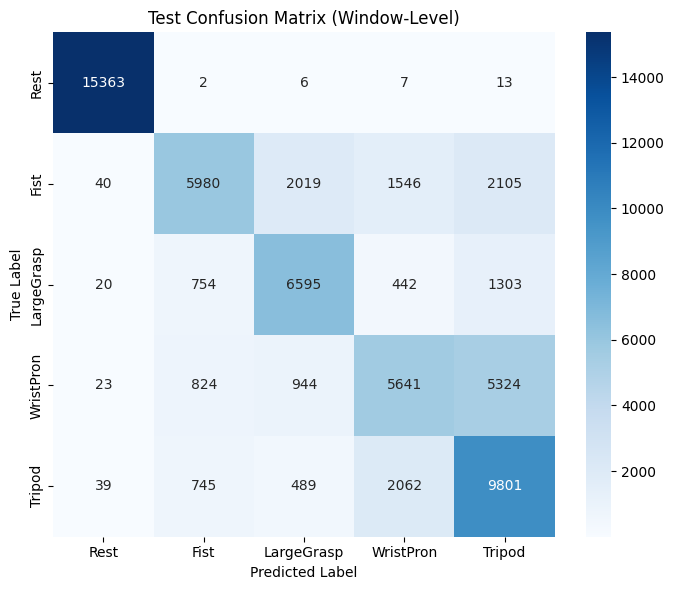

Confusion matrix saved! ✅


In [ ]:
ckpt_path = os.path.join(BASE_DIR, config["output_dir"], "best_model.pth")
ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
model = ResCNN().to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Best checkpoint loaded successfully! ✅")

# bandpass_filter / notch_filter already defined above; redefined here for standalone cell execution
def bandpass_filter(emg, lowcut=20, highcut=450, fs=FS, order=4):
    if emg.ndim == 1:
        emg = emg[np.newaxis, :]
    nyq = 0.5 * fs
    sos = butter(order, [lowcut / nyq, highcut / nyq], btype="band", output="sos")
    filt = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filt[ch] = sosfiltfilt(sos, emg[ch])
    return filt

def notch_filter(emg, freq=50, fs=FS, quality=30):
    if emg.ndim == 1:
        emg = emg[np.newaxis, :]
    w0 = freq / (0.5 * fs)
    b, a = iirnotch(w0, quality)
    filt = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filt[ch] = filtfilt(b, a, emg[ch])
    return filt

def build_windows(subject_ids):
    windows, labels = [], []
    for sid in subject_ids:
        emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
        lbls = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_labels.npy"))
        emg_t = bandpass_filter(emg.T)
        emg_t = notch_filter(emg_t)
        emg_filt = emg_t.T.astype(np.float32)
        ch_mean = emg_filt.mean(axis=0, keepdims=True)
        ch_std = emg_filt.std(axis=0, keepdims=True) + 1e-8
        emg_filt = (emg_filt - ch_mean) / ch_std
        for i in range(0, len(emg_filt) - WINDOW_SIZE, WINDOW_STEP):
            c = i + WINDOW_SIZE // 2
            l = lbls[c]
            if l not in GESTURE_MAP:
                continue
            windows.append(emg_filt[i:i + WINDOW_SIZE])
            labels.append(GESTURE_MAP[l])
    return np.array(windows, dtype=np.float32), np.array(labels, dtype=np.int64)

test_windows, test_labels = build_windows(test_ids)
test_tensor = torch.from_numpy(test_windows).permute(0, 2, 1).to(device)

all_preds = []
batch = 256
with torch.no_grad():
    for i in range(0, len(test_tensor), batch):
        out = model(test_tensor[i:i+batch])
        all_preds.append(out.argmax(-1).cpu().numpy())
all_preds = np.concatenate(all_preds)

test_acc = accuracy_score(test_labels, all_preds) * 100
test_f1 = f1_score(test_labels, all_preds, average="macro")

print(f"\nWindow-Level Results:")
print(f"  Accuracy:  {test_acc:.2f}%")
print(f"  Macro F1:  {test_f1:.4f}")
print(f"\n{classification_report(test_labels, all_preds, target_names=GESTURE_NAMES)}")

cm = confusion_matrix(test_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=ax)
ax.set_title("Test Confusion Matrix (Window-Level)")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "confusion_matrix.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Confusion matrix saved! ✅")


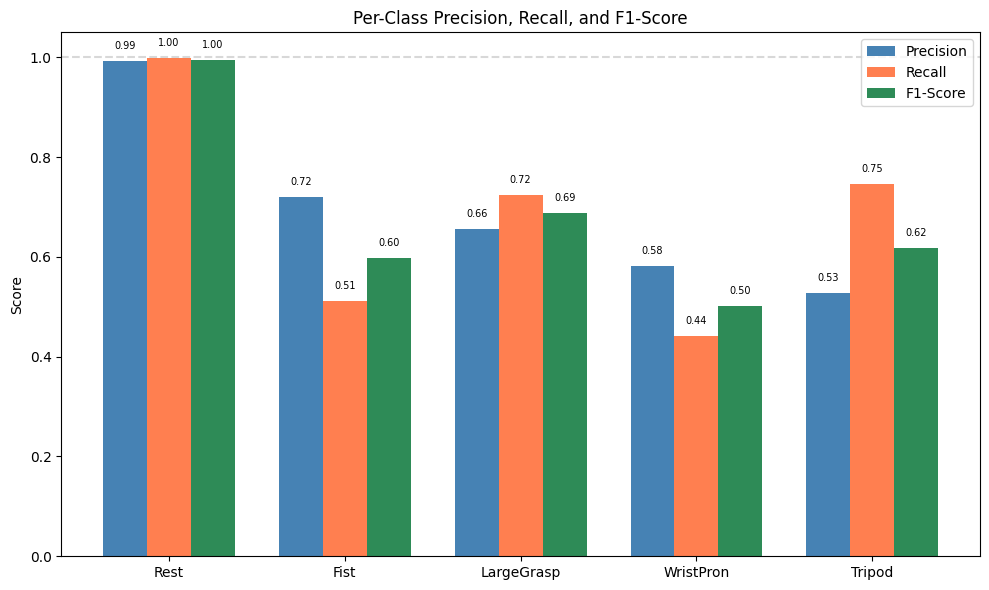

Per-class PRF1 bar chart saved! ✅


In [ ]:

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels, all_preds, average=None, labels=list(range(N_CLASSES))
)

x = np.arange(N_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label="Precision", color="steelblue")
bars2 = ax.bar(x, recall, width, label="Recall", color="coral")
bars3 = ax.bar(x + width, f1, width, label="F1-Score", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(GESTURE_NAMES)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision, Recall, and F1-Score")
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)

# Annotate bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "per_class_prf1.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Per-class PRF1 bar chart saved! ✅")


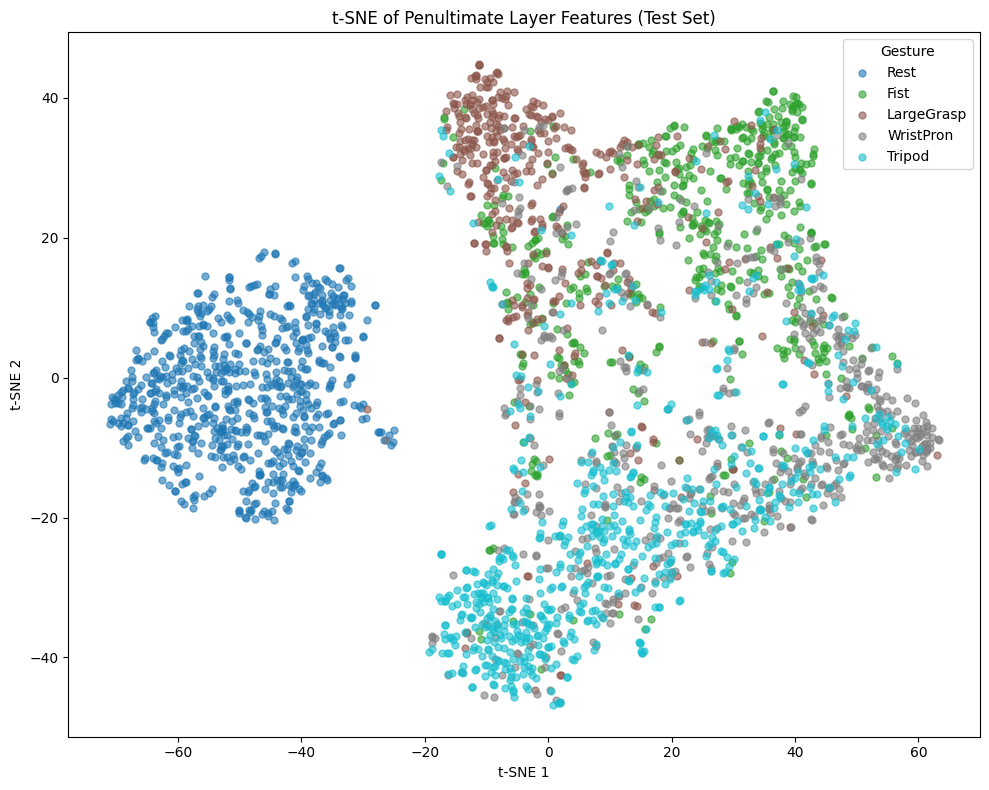

t-SNE plot saved! ✅


In [ ]:

features_list = []
def hook(module, input, output):
    features_list.append(output.squeeze(-1).cpu().numpy())
handle = model.pool.register_forward_hook(hook)
with torch.no_grad():
    for s in range(0, len(test_tensor), 256):
        _ = model(test_tensor[s:s + 256])
handle.remove()
features = np.concatenate(features_list)

if len(features) > 3000:
    idx = np.random.choice(len(features), 3000, replace=False)
    feat_sub = features[idx]
    lbl_sub = test_labels[idx]
else:
    feat_sub = features
    lbl_sub = test_labels

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
emb = tsne.fit_transform(feat_sub)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
for i, name in enumerate(GESTURE_NAMES):
    mask = lbl_sub == i
    ax.scatter(emb[mask, 0], emb[mask, 1], c=[colors[i]], label=name, alpha=0.6, s=25)
ax.legend(title="Gesture", loc="best")
ax.set_title("t-SNE of Penultimate Layer Features (Test Set)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "tsne_features.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"t-SNE plot saved! ✅")


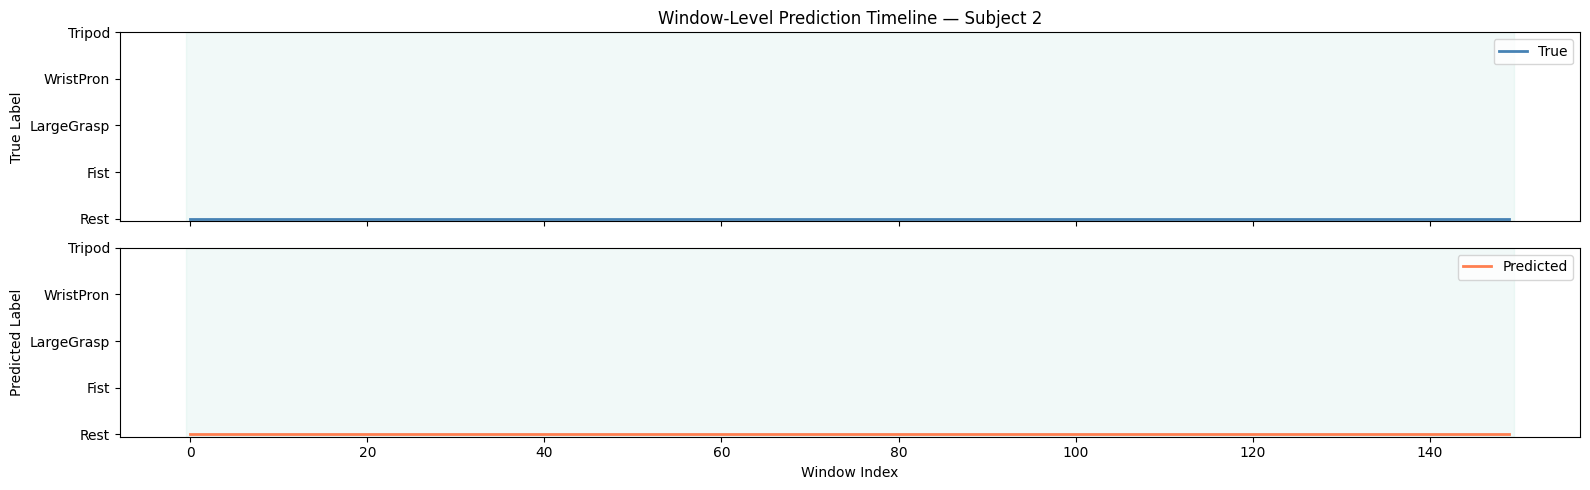

Prediction timeline saved! ✅


In [ ]:
sid = test_ids[0]
emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
lbls = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_labels.npy"))
emg_t = bandpass_filter(emg.T)
emg_t = notch_filter(emg_t)
emg_filt = emg_t.T.astype(np.float32)
ch_mean = emg_filt.mean(axis=0, keepdims=True)
ch_std = emg_filt.std(axis=0, keepdims=True) + 1e-8
emg_filt = (emg_filt - ch_mean) / ch_std

sw, sl, sp = [], [], []
for i in range(0, len(emg_filt) - WINDOW_SIZE, WINDOW_STEP):
    c = i + WINDOW_SIZE // 2
    l = lbls[c]
    if l not in GESTURE_MAP:
        continue
    sw.append(emg_filt[i:i + WINDOW_SIZE])
    sl.append(GESTURE_MAP[l])
    sp.append(c)
wt = torch.from_numpy(np.array(sw, dtype=np.float32)).permute(0, 2, 1).to(device)
preds = []
with torch.no_grad():
    for s in range(0, len(wt), 256):
        preds.append(model(wt[s:s + 256]).argmax(-1).cpu().numpy())
preds = np.concatenate(preds)
sl = np.array(sl)

n_show = min(150, len(sl))
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

axes[0].step(range(n_show), sl[:n_show], where="mid", color="steelblue", linewidth=2, label="True")
axes[0].set_ylabel("True Label")
axes[0].set_yticks(range(N_CLASSES))
axes[0].set_yticklabels(GESTURE_NAMES)
axes[0].set_title(f"Window-Level Prediction Timeline — Subject {sid}")
axes[0].legend(loc="upper right")

axes[1].step(range(n_show), preds[:n_show], where="mid", color="coral", linewidth=2, label="Predicted")
axes[1].set_ylabel("Predicted Label")
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_yticklabels(GESTURE_NAMES)
axes[1].set_xlabel("Window Index")
axes[1].legend(loc="upper right")

colors_bg = plt.cm.Set3(np.linspace(0, 1, N_CLASSES))
current_label = sl[0]
start_idx = 0
for i in range(1, n_show):
    if sl[i] != current_label:
        for ax in axes:
            ax.axvspan(start_idx - 0.5, i - 0.5, alpha=0.12, color=colors_bg[current_label])
        current_label = sl[i]
        start_idx = i
for ax in axes:
    ax.axvspan(start_idx - 0.5, n_show - 0.5, alpha=0.12, color=colors_bg[current_label])

plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "prediction_timeline.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Prediction timeline saved! ✅")


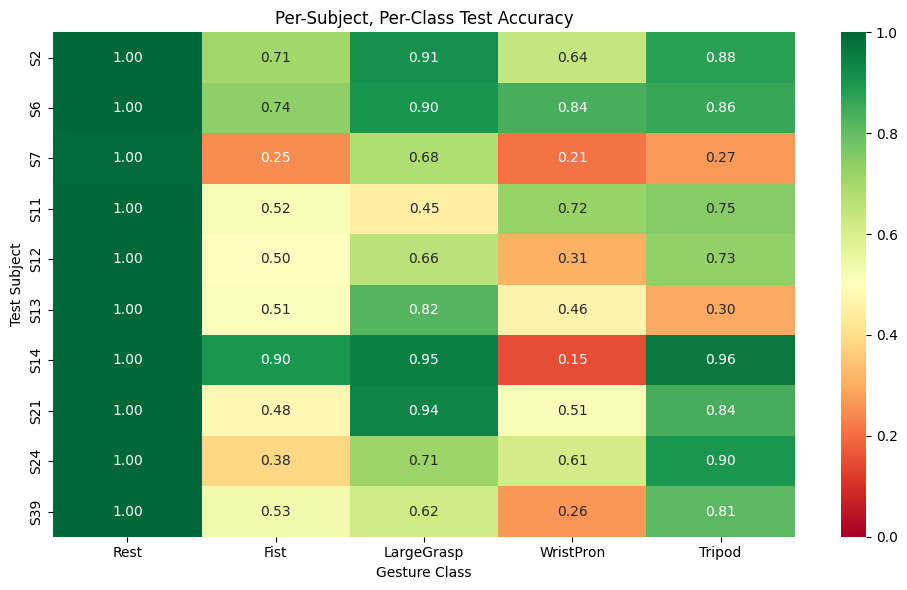

Per-subject accuracy heatmap saved! ✅


In [ ]:
from sklearn.metrics import accuracy_score

subj_acc = np.zeros((len(test_ids), N_CLASSES))
for idx, sid in enumerate(test_ids):
    sw, sl = build_windows([sid])
    st = torch.from_numpy(sw).permute(0, 2, 1).to(device)
    sp = []
    with torch.no_grad():
        for s in range(0, len(st), 256):
            sp.append(model(st[s:s + 256]).argmax(-1).cpu().numpy())
    sp = np.concatenate(sp)
    sl = np.array(sl)
    for c in range(N_CLASSES):
        mask = sl == c
        if mask.sum() > 0:
            subj_acc[idx, c] = accuracy_score(sl[mask], sp[mask])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(subj_acc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            xticklabels=GESTURE_NAMES, yticklabels=[f"S{sid}" for sid in test_ids], ax=ax)
ax.set_title("Per-Subject, Per-Class Test Accuracy")
ax.set_xlabel("Gesture Class")
ax.set_ylabel("Test Subject")
plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "per_subject_accuracy.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Per-subject accuracy heatmap saved! ✅")


## 12. Majority Voting Evaluation 🗳️


Window Accuracy:      69.87%
Window Macro F1:      0.6805

Hard Voting Accuracy: 89.78% (489 segments)
Hard Voting Macro F1: 0.8316

Hard Voting Classification Report:
              precision    recall  f1-score   support

        Rest       1.00      1.00      1.00       249
        Fist       1.00      0.83      0.91        60
  LargeGrasp       0.88      0.98      0.93        60
   WristPron       0.71      0.53      0.61        60
      Tripod       0.63      0.82      0.71        60

    accuracy                           0.90       489
   macro avg       0.84      0.83      0.83       489
weighted avg       0.90      0.90      0.90       489


Soft Voting Accuracy: 89.37% (489 segments)
Soft Voting Macro F1: 0.8254


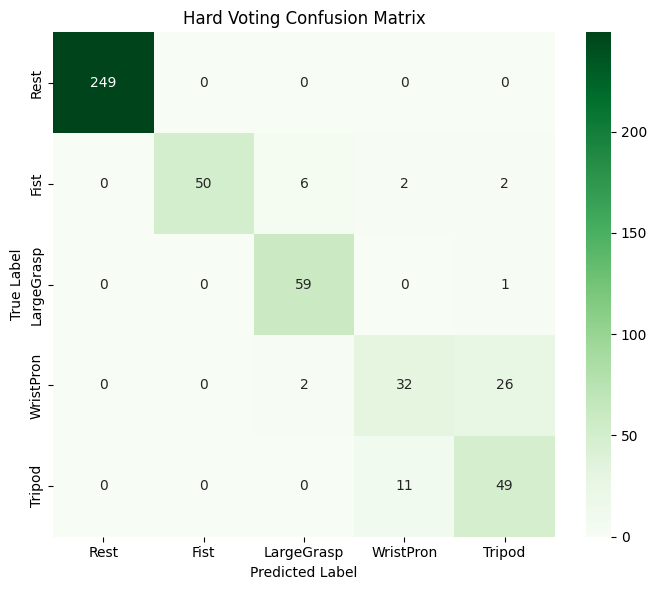


| Metric           | Window-Level | Hard Vote | Soft Vote |
|------------------|--------------|-----------|-----------|
| Accuracy         | 69.87%       | 89.78%    | 89.37%    |
| Macro F1         | 0.6805     | 0.8316  | 0.8254  |
Majority voting evaluation complete! ✅


In [ ]:
def evaluate_majority_voting(subject_ids):
    all_wpred, all_wtrue = [], []
    ghard_p, ghard_t = [], []
    gsoft_p, gsoft_t = [], []
    for sid in subject_ids:
        emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
        labels_full = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_labels.npy"))
        emg_t = bandpass_filter(emg.T)
        emg_t = notch_filter(emg_t)
        emg_filt = emg_t.T.astype(np.float32)
        ch_mean = emg_filt.mean(axis=0, keepdims=True)
        ch_std = emg_filt.std(axis=0, keepdims=True) + 1e-8
        emg_filt = (emg_filt - ch_mean) / ch_std

        sw, sl, sp = [], [], []
        for i in range(0, len(emg_filt) - WINDOW_SIZE, WINDOW_STEP):
            c = i + WINDOW_SIZE // 2
            l = labels_full[c]
            if l not in GESTURE_MAP:
                continue
            sw.append(emg_filt[i:i + WINDOW_SIZE])
            sl.append(GESTURE_MAP[l])
            sp.append(c)
        if not sw:
            continue
        wt = torch.from_numpy(np.array(sw, dtype=np.float32)).permute(0, 2, 1)
        probs_all, preds_all = [], []
        with torch.no_grad():
            for s in range(0, len(wt), 256):
                b = wt[s:s + 256].to(device)
                out = model(b)
                probs_all.append(F.softmax(out, dim=-1).cpu().numpy())
                preds_all.append(out.argmax(-1).cpu().numpy())
        probs_all = np.concatenate(probs_all)
        preds_all = np.concatenate(preds_all)
        sl = np.array(sl)

        all_wpred.extend(preds_all.tolist())
        all_wtrue.extend(sl.tolist())

        seg_s = 0
        for i in range(1, len(sl)):
            time_gap = sp[i] - sp[i-1]
            if sl[i] != sl[i-1] or time_gap > 2 * WINDOW_STEP:
                if i - seg_s >= 3:
                    tl = int(sl[seg_s])
                    hv = Counter(preds_all[seg_s:i].tolist()).most_common(1)[0][0]
                    sv = int(probs_all[seg_s:i].sum(axis=0).argmax())
                    ghard_p.append(hv); gsoft_p.append(sv)
                    ghard_t.append(tl); gsoft_t.append(tl)
                seg_s = i
        if len(sl) - seg_s >= 3:
            tl = int(sl[seg_s])
            hv = Counter(preds_all[seg_s:].tolist()).most_common(1)[0][0]
            sv = int(probs_all[seg_s:].sum(axis=0).argmax())
            ghard_p.append(hv); gsoft_p.append(sv)
            ghard_t.append(tl); gsoft_t.append(tl)

    results = {
        "window_acc": accuracy_score(all_wtrue, all_wpred) * 100,
        "window_f1": f1_score(all_wtrue, all_wpred, average="macro"),
    }
    for name, p, t in [("hard", ghard_p, ghard_t), ("soft", gsoft_p, gsoft_t)]:
        if t:
            results[f"{name}_acc"] = accuracy_score(t, p) * 100
            results[f"{name}_f1"] = f1_score(t, p, average="macro")
            results[f"{name}_cm"] = confusion_matrix(t, p)
            results[f"{name}_n"] = len(t)
            results[f"{name}_preds"] = p
            results[f"{name}_true"] = t
        else:
            results[f"{name}_acc"] = 0.0
            results[f"{name}_f1"] = 0.0
            results[f"{name}_cm"] = None
            results[f"{name}_n"] = 0
            results[f"{name}_preds"] = []
            results[f"{name}_true"] = []
    return results

mv = evaluate_majority_voting(test_ids)

print(f"Window Accuracy:      {mv['window_acc']:.2f}%")
print(f"Window Macro F1:      {mv['window_f1']:.4f}")
print(f"\nHard Voting Accuracy: {mv['hard_acc']:.2f}% ({mv['hard_n']} segments)")
print(f"Hard Voting Macro F1: {mv['hard_f1']:.4f}")
print(f"\nHard Voting Classification Report:")
print(classification_report(mv["hard_true"], mv["hard_preds"], target_names=GESTURE_NAMES))
print(f"\nSoft Voting Accuracy: {mv['soft_acc']:.2f}% ({mv['soft_n']} segments)")
print(f"Soft Voting Macro F1: {mv['soft_f1']:.4f}")

if mv["hard_cm"] is not None:
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(mv["hard_cm"], annot=True, fmt="d", cmap="Greens",
                xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=ax)
    ax.set_title("Hard Voting Confusion Matrix")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

print("\n| Metric           | Window-Level | Hard Vote | Soft Vote |")
print("|------------------|--------------|-----------|-----------|")
print(f"| Accuracy         | {mv['window_acc']:.2f}%       | {mv['hard_acc']:.2f}%    | {mv['soft_acc']:.2f}%    |")
print(f"| Macro F1         | {mv['window_f1']:.4f}     | {mv['hard_f1']:.4f}  | {mv['soft_f1']:.4f}  |")

print("Majority voting evaluation complete! ✅")


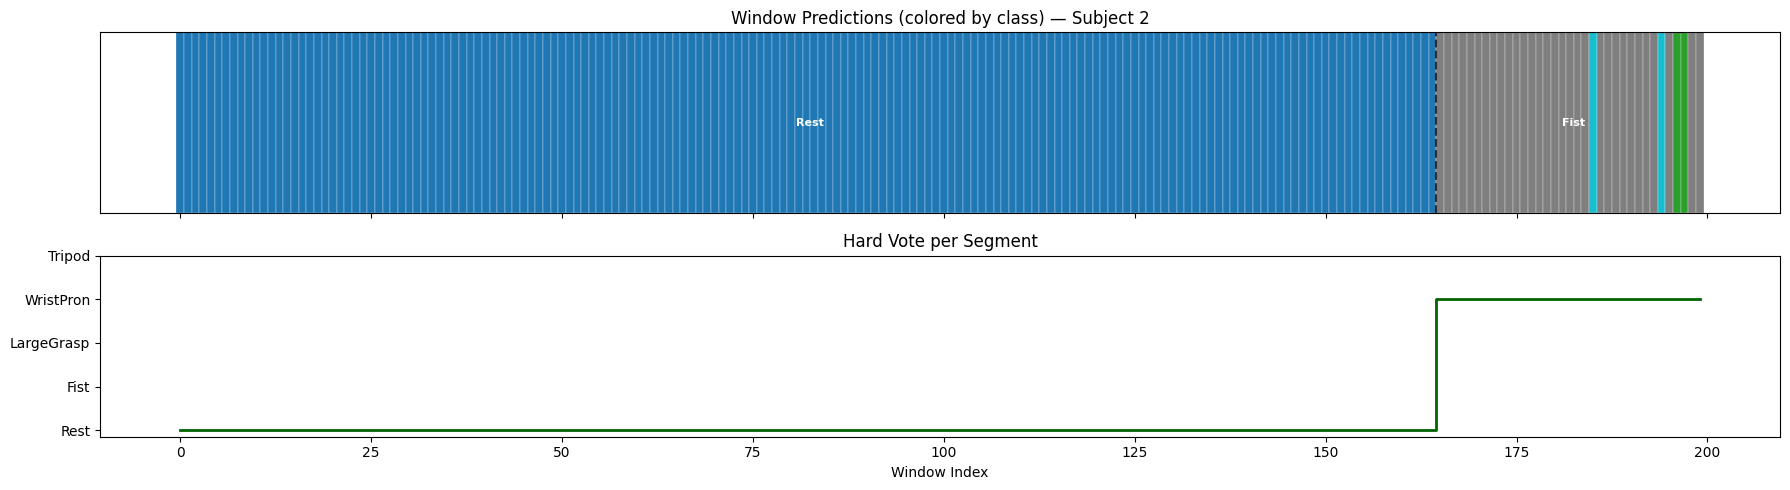

Voting segment plot saved! ✅


In [ ]:
sid = test_ids[0]
emg = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_emg.npy"))
labels_full = np.load(os.path.join(BASE_DIR, "data", "subset", f"S{sid}_labels.npy"))
emg_t = bandpass_filter(emg.T)
emg_t = notch_filter(emg_t)
emg_filt = emg_t.T.astype(np.float32)
ch_mean = emg_filt.mean(axis=0, keepdims=True)
ch_std = emg_filt.std(axis=0, keepdims=True) + 1e-8
emg_filt = (emg_filt - ch_mean) / ch_std

sw, sl, sp = [], [], []
for i in range(0, len(emg_filt) - WINDOW_SIZE, WINDOW_STEP):
    c = i + WINDOW_SIZE // 2
    l = labels_full[c]
    if l not in GESTURE_MAP:
        continue
    sw.append(emg_filt[i:i + WINDOW_SIZE])
    sl.append(GESTURE_MAP[l])
    sp.append(c)
wt = torch.from_numpy(np.array(sw, dtype=np.float32)).permute(0, 2, 1).to(device)
preds_all = []
with torch.no_grad():
    for s in range(0, len(wt), 256):
        preds_all.append(model(wt[s:s + 256]).argmax(-1).cpu().numpy())
preds_all = np.concatenate(preds_all)
sl = np.array(sl)

segments = []
seg_s = 0
for i in range(1, len(sl)):
    if sl[i] != sl[i-1] or sp[i] - sp[i-1] > 2 * WINDOW_STEP:
        segments.append((seg_s, i, int(sl[seg_s])))
        seg_s = i
segments.append((seg_s, len(sl), int(sl[seg_s])))

n_show = min(200, len(sl))
colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

fig, axes = plt.subplots(2, 1, figsize=(18, 5), sharex=True)

for i in range(n_show):
    axes[0].bar(i, 1, color=colors[preds_all[i]], width=1, edgecolor="white", linewidth=0.2)
axes[0].set_ylim(0, 1)
axes[0].set_yticks([])
axes[0].set_title(f"Window Predictions (colored by class) — Subject {sid}")
seg_start = 0
for i in range(1, n_show):
    if sl[i] != sl[i-1]:
        axes[0].axvline(i - 0.5, color="black", linestyle="--", alpha=0.7)
        mid = (seg_start + i) / 2
        axes[0].text(mid, 0.5, GESTURE_NAMES[sl[seg_start]], ha="center", va="center",
                     fontsize=8, color="white", fontweight="bold")
        seg_start = i
mid = (seg_start + n_show) / 2
axes[0].text(mid, 0.5, GESTURE_NAMES[sl[seg_start]], ha="center", va="center",
             fontsize=8, color="white", fontweight="bold")

vote_y = []
for seg_start, seg_end, true_lbl in segments:
    if seg_start >= n_show:
        break
    actual_end = min(seg_end, n_show)
    hv = Counter(preds_all[seg_start:actual_end].tolist()).most_common(1)[0][0]
    vote_y.extend([hv] * (actual_end - seg_start))
axes[1].step(range(len(vote_y)), vote_y, where="mid", color="darkgreen", linewidth=2)
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_yticklabels(GESTURE_NAMES)
axes[1].set_xlabel("Window Index")
axes[1].set_title("Hard Vote per Segment")

plt.tight_layout()
out_path = os.path.join(BASE_DIR, "results", "voting_segments.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Voting segment plot saved! ✅")


## 13. Results Summary 🏆

| Metric | Window-Level | Hard Vote |
|---|---|---|
| Accuracy | 69.87% | 89.78% |
| Macro F1 | 0.68 | 0.83 |
| Rest F1 | 1.00 |1.00 |
| Fist F1 | 0.60 | 0.91 |
| LargeGrasp F1 | 0.69 | 0.95 |
| WristPron F1 | 0.50 | 0.61 |
| Tripod F1 | 0.62 | 0.71 |

---


## 14. Data Leakage Prevention Checklist 📋

- [✅] Test subjects never present in training or validation
- [✅] Per-subject normalization (no cross-subject data sharing)
- [✅] Hyperparameters tuned on validation only
- [✅] Test set accessed once, in evaluation section
- [✅] No subject ID passed to classifier

---


## 15. References 📚

1. Atzori, M., et al. (2014). "Electromyography data for non-invasive naturally-controlled robotic hand prostheses." *Scientific Data*, 1, 140053. (NinaPro DB2)

---
